Isaac Noe
9/8/26
Lab 2 — Energy-Tracking Projectile

In [13]:
import numpy as np
import matplotlib.pyplot as plt

Part A — Add Energy Tracking (25 points)

In [14]:
# Part 1
# Defining the Function
def simulate_projectile_2d(v0, theta_deg, dt, m, g=9.81):

    # Initial conditions:
    angle = np.radians(theta_deg)
    x, y = 0.0, 0.0
    vx, vy = v0 * np.cos(angle), v0 * np.sin(angle)

    # Storage lists for plotting
    data = {'t': [0], 'x': [x], 'y': [y], 'vx': [vx], 'vy': [vy],
        'KE': [0.5*m*(vx**2+vy**2)], 'PE': [m*g*y], 'E': [0.5*m*(vx**2+vy**2)+m*g*y]}

    t = 0.0
    while y >= 0.0:
        # Compute acceleration (only gravity here)
        ax = 0.0
        ay = -g

        # Speed
        speed = np.sqrt(vx**2 + vy**2)

        # Update position (Euler)
        x = x + vx * dt
        y = y + vy * dt
        
        # Update velocity (Euler)
        vx = vx + ax * dt
        vy = vy + ay * dt

        t += dt

        # Energy tracking
        KE = 0.5 * m * (vx**2 + vy**2)
        PE = m * g * y
        E  = KE + PE
        
        data['t'].append(t)
        data['x'].append(x); data['y'].append(y)
        data['vx'].append(vx); data['vy'].append(vy)
        data['KE'].append(KE); data['PE'].append(PE); data['E'].append(E)
    return  data['t'], data['x'], data['y'], data['vx'], data['vy'], data['KE'], data['PE'], data['E']

In [15]:
# Part 2 Setting Conditions
t, x, y, vx, vy, ke, pe, e = simulate_projectile_2d(30, 50, 0.01, 1)

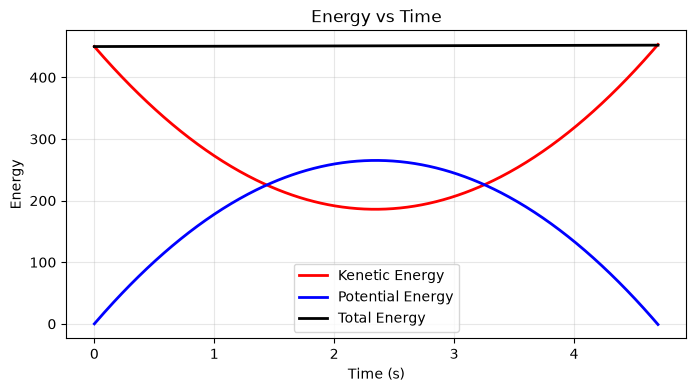

In [16]:
# Part 3
# Plotting Graph 1
plt.figure(figsize=(8, 4))
plt.plot(t, ke, color='red', linewidth=2, label="Kenetic Energy")
plt.plot(t, pe,color="blue", linewidth=2, label="Potential Energy")
plt.plot(t, e,color="black", linewidth=2, label="Total Energy")
plt.xlabel('Time (s)')
plt.ylabel('Energy')
plt.title('Energy vs Time')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

This graph shows the relationship of Kenetic, Potential, and Total Energy as a function of time.

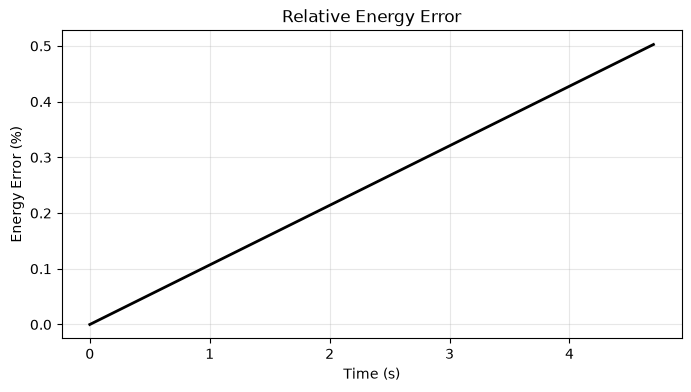

In [17]:
# Plotting Graph 2
E0 = e[0]
E_err = [(E - E0) / abs(E0) * 100 for E in e]
plt.figure(figsize=(8, 4))
plt.plot(t, E_err, color='black', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Energy Error (%)')
plt.title('Relative Energy Error')
plt.grid(True, alpha=0.3)
plt.show()

This graph shows energy drift as time progresses.

In [18]:
# Part 4
# Finding maximum absolute energy drift 
# and expressing it as a percentage of the initial energy
abs_e_drift = abs(e-e[0])
max_abs_e_drift = max(abs_e_drift)
print(f'The maximum absolute energy drift over the flight is {max_abs_e_drift:.3}')
print(f'and it as a percentage of the initial energy is {(max_abs_e_drift/e[0])*100:.3}%')

The maximum absolute energy drift over the flight is 2.26
and it as a percentage of the initial energy is 0.503%


✎ Interpret it: With standard Euler, you should see E total slowly grow over the flight — the simulation invents energy from nothing. In 2–3 sentences, explain what you observe. Is the drift steady, or does it accelerate? Roughly what percentage of the initial energy is gained by the time the projectile lands?

The energy drift is steady, and when the projectile lands roughly 0.503% of the initial energy is gained.

Part B — Euler vs. Euler-Cromer (35 points)

In [22]:
# Part 1
# Defining the function
def simulate(method, dt, v0, angle_deg, g=9.81, m=1):
    """Simulate projectile with energy tracking.
    method: 'euler' or 'euler-cromer'
    """
    angle = np.radians(angle_deg)
    x, y = 0.0, 0.0
    vx, vy = v0 * np.cos(angle), v0 * np.sin(angle)

    # Storage lists for plotting
    data = {'t': [0], 'x': [x], 'y': [y], 'vx': [vx], 'vy': [vy],
        'KE': [0.5*m*(vx**2+vy**2)], 'PE': [m*g*y], 'E': [0.5*m*(vx**2+vy**2)+m*g*y]}
    t = 0.0

    while t < 10.0 and y >= 0:
        ax, ay = 0.0, -g

        if method == 'euler':
            x  += vx * dt        # position uses OLD velocity
            y  += vy * dt
            vx += ax * dt
            vy += ay * dt
        elif method == 'euler-cromer':
            vx += ax * dt        # velocity updated FIRST
            vy += ay * dt
            x  += vx * dt        # position uses NEW velocity
            y  += vy * dt

        t += dt
        # Energy tracking

        KE = 0.5 * m * (vx**2 + vy**2)
        PE = m * g * y
        E  = KE + PE

        data['t'].append(t)
        data['x'].append(x); data['y'].append(y)
        data['vx'].append(vx); data['vy'].append(vy)
        data['KE'].append(KE); data['PE'].append(PE); data['E'].append(E)
    return  data['t'], data['x'], data['y'], data['vx'], data['vy'], data['KE'], data['PE'], data['E']

In [24]:
# Part 2
# Running both methods
te, xe, ye, vxe, vye, kee, pee, ee = simulate('euler', 0.01, 30, 50, 9.81, 1)
tc, xc, yc, vxc, vyc, kec, pec, ec = simulate('euler-cromer', 0.01, 30, 50, 9.81, 1)

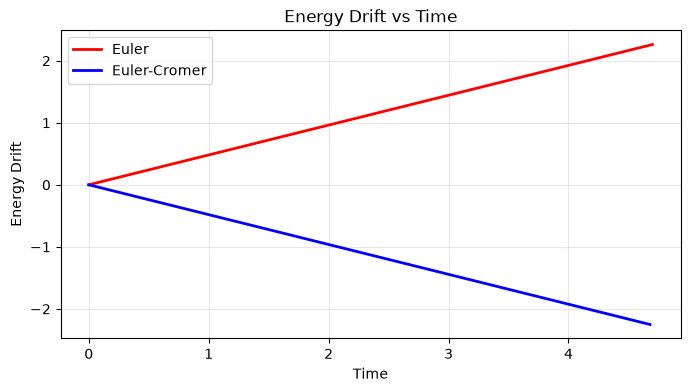

In [30]:
# Part 3
# Plotting the Graph
plt.figure(figsize=(8, 4))
plt.plot(te, ee-ee[0], color='red',label='Euler', linewidth=2)
plt.plot(tc, ec-ec[0], color='blue',label='Euler-Cromer', linewidth=2)
plt.xlabel('Time')
plt.ylabel('Energy Drift')
plt.title('Energy Drift vs Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

This graph show the energy drift of both euler and euler-cromer as a funtion of time.

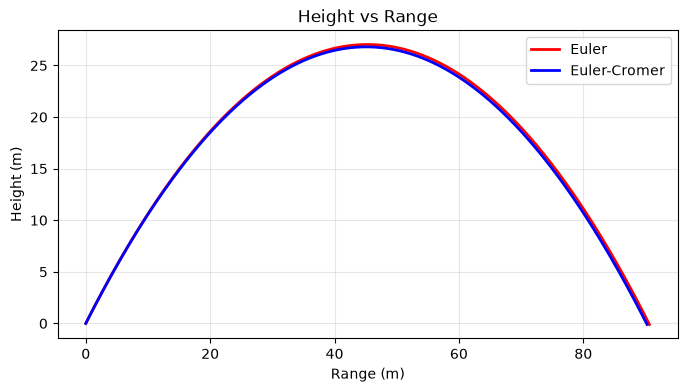

In [32]:
# Part 4
# Plotting the Other Graph
plt.figure(figsize=(8, 4))
plt.plot(xe, ye, color='red',label='Euler', linewidth=2)
plt.plot(xc, yc, color='blue',label='Euler-Cromer', linewidth=2)
plt.xlabel('Range (m)')
plt.ylabel('Height (m)')
plt.title('Height vs Range')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()